### References
- PointVector: https://openaccess.thecvf.com/content/CVPR2023/papers/Deng_PointVector_A_Vector_Representation_in_Point_Cloud_Analysis_CVPR_2023_paper.pdf
- Particle Transformer / JetClass: https://arxiv.org/abs/2202.03772
- Thanh Nguyen GSoC 2025: https://medium.com/@thanhnguyen14401/gsoc-2025-with-ml4sci-event-classification-with-masked-transformer-autoencoders-6da369d42140

## 1. Installation



In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

import pennylane as qml
import wandb

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"Pennylane version: {qml.__version__}")

test_dev = qml.device('lightning.qubit', wires=2)
print("lightning.qubit: Available")
QUANTUM_DEVICE = 'lightning.qubit'


# Reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

/usr/local/lib/python3.12/dist-packages/pennylane/__init__.py:212: PennyLaneDeprecationWarning: PennyLane v0.44 has dropped maintainence support for NumPy < 2.0.0. You have version 1.26.4 installed. Future versions of PennyLane will not work with NumPy<2.0. Please consider upgrading NumPy using `python -m pip install numpy --upgrade`. 
  warnings.warn(


PyTorch device: cuda
PyTorch version: 2.10.0+cu128
Pennylane version: 0.44.1
lightning.qubit: Available


## 2. Data Loading

We use the Pythia8 QuarkGluon dataset via EnergyFlow for prototyping.  

In [3]:
import energyflow as ef

print("Loading QuarkGluon dataset...")
X_raw, y = ef.qg_jets.load(num_data=100000, pad=True, ncol=4,
                           generator='pythia', with_bc=False)

print(f"Raw shape: {X_raw.shape}")  # (N, max_particles, 4)
print(f"Features: [pT, eta, phi, pid]")
print(f"Labels: {np.unique(y)} (0=gluon, 1=quark)")
print(f"Class balance: {np.mean(y):.3f} quark fraction")

Loading QuarkGluon dataset...
Raw shape: (100000, 139, 4)
Features: [pT, eta, phi, pid]
Labels: [0. 1.] (0=gluon, 1=quark)
Class balance: 0.500 quark fraction


In [4]:
def preprocess_jets(X_raw, max_particles=64):
    #Output shape: (N, max_particles, 4) with features [pT_norm, eta_rel, phi_rel, log_pT
    n_jets = X_raw.shape[0]
    X = np.zeros((n_jets, max_particles, 4), dtype=np.float32)
    mask = np.zeros((n_jets, max_particles), dtype=np.float32)

    for i in range(n_jets):
        pt = X_raw[i, :, 0]
        eta = X_raw[i, :, 1]
        phi = X_raw[i, :, 2]

        valid = pt > 0
        n_valid = valid.sum()
        if n_valid == 0:
            continue

        pt_v, eta_v, phi_v = pt[valid], eta[valid], phi[valid]

        sort_idx = np.argsort(-pt_v)[:min(n_valid, max_particles)]
        pt_s = pt_v[sort_idx]
        eta_s = eta_v[sort_idx]
        phi_s = phi_v[sort_idx]

        total_pt = pt_s.sum()
        eta_center = np.average(eta_s, weights=pt_s)
        phi_center = np.average(phi_s, weights=pt_s)

        eta_rel = eta_s - eta_center
        phi_rel = np.arctan2(np.sin(phi_s - phi_center), np.cos(phi_s - phi_center))
        pt_norm = pt_s / total_pt
        log_pt = np.log(pt_s + 1e-6)

        n_keep = len(sort_idx)
        X[i, :n_keep, 0] = pt_norm
        X[i, :n_keep, 1] = eta_rel
        X[i, :n_keep, 2] = phi_rel
        X[i, :n_keep, 3] = log_pt / 10.0  # Scale log_pT
        mask[i, :n_keep] = 1.0

    return X, mask

X, mask = preprocess_jets(X_raw, max_particles=64)
print(f"Processed shape: {X.shape}")
print(f"Features per particle: [pT_norm, eta_rel, phi_rel, log_pT]")

Processed shape: (100000, 64, 4)
Features per particle: [pT_norm, eta_rel, phi_rel, log_pT]


In [5]:

X_train, X_temp, y_train, y_temp, mask_train, mask_temp = train_test_split(
    X, y, mask, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test, mask_val, mask_test = train_test_split(
    X_temp, y_temp, mask_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 80000 | Val: 10000 | Test: 10000


## 3. Physics-Motivated Augmentations

In [6]:
class JetAugmentation:

    def __init__(self, rotate=True, dropout_prob=0.1,
                 pt_smear=0.05, translate=0.02, biased_dropout=True):
        self.rotate = rotate
        self.dropout_prob = dropout_prob
        self.pt_smear = pt_smear
        self.translate = translate
        self.biased_dropout = biased_dropout

    def __call__(self, x, mask):
        x_aug = x.copy()
        mask_aug = mask.copy()
        valid_idx = np.where(mask > 0)[0]

        if len(valid_idx) == 0:
            return x_aug, mask_aug
        if self.rotate:
            angle = np.random.uniform(0, 2 * np.pi)
            x_aug[valid_idx, 2] += angle
            x_aug[valid_idx, 2] = np.arctan2(
                np.sin(x_aug[valid_idx, 2]),
                np.cos(x_aug[valid_idx, 2]))

        if self.dropout_prob > 0 and len(valid_idx) > 5:
            if self.biased_dropout:
                position = np.arange(len(valid_idx))
                drop_prob = self.dropout_prob * (1 + position / len(valid_idx))
                drop_prob = np.clip(drop_prob, 0, 0.5)  # Cap at 50%
                keep = np.random.random(len(valid_idx)) > drop_prob
            else:
                keep = np.random.random(len(valid_idx)) > self.dropout_prob

            if keep.sum() < 5:
                keep[:5] = True
            drop_idx = valid_idx[~keep]
            x_aug[drop_idx] = 0
            mask_aug[drop_idx] = 0

        valid_idx = np.where(mask_aug > 0)[0]

        if self.pt_smear > 0 and len(valid_idx) > 0:
            noise = np.random.normal(0, self.pt_smear, len(valid_idx))
            x_aug[valid_idx, 0] *= (1 + noise)
            x_aug[valid_idx, 0] = np.maximum(x_aug[valid_idx, 0], 1e-6)
            x_aug[valid_idx, 0] /= x_aug[valid_idx, 0].sum()

        if self.translate > 0 and len(valid_idx) > 0:
            x_aug[valid_idx, 1] += np.random.normal(0, self.translate)
            x_aug[valid_idx, 2] += np.random.normal(0, self.translate)
            x_aug[valid_idx, 2] = np.arctan2(
                np.sin(x_aug[valid_idx, 2]),
                np.cos(x_aug[valid_idx, 2]))

        return x_aug, mask_aug

## 4. Dataset Classes

In [7]:
class JetContrastiveDataset(Dataset):

    def __init__(self, X, mask, y=None, augmentation=None):
        self.X = X.astype(np.float32)
        self.mask = mask.astype(np.float32)
        self.y = y
        self.aug = augmentation

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x, m = self.X[idx], self.mask[idx]

        if self.aug:
            x1, m1 = self.aug(x, m)
            x2, m2 = self.aug(x, m)
        else:
            x1, m1 = x.copy(), m.copy()
            x2, m2 = x.copy(), m.copy()

        x1 = torch.from_numpy(x1).T  # (4, 64)
        x2 = torch.from_numpy(x2).T
        m1 = torch.from_numpy(m1)
        m2 = torch.from_numpy(m2)

        if self.y is not None:
            return x1, m1, x2, m2, self.y[idx]
        return x1, m1, x2, m2


class JetDataset(Dataset):

    def __init__(self, X, mask, y):
        self.X = torch.from_numpy(X.astype(np.float32)).permute(0, 2, 1)  # (N, 4, 64)
        self.mask = torch.from_numpy(mask.astype(np.float32))
        self.y = torch.from_numpy(y.astype(np.int64))

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.mask[idx], self.y[idx]

## 5. PointVector Encoder

I initially used standard PointNet-style aggregation, but it struggled with asymmetric jet structures (especially multi-prong cases). Switching to PointVector helped because it weights neighbors based on direction, which better matches how energy is distributed in jets

The neighbor contributions depend on their relative direction with features.For ex: A particle at (Δη=0.1, Δφ=0) contributes differently than one at (Δη=0, Δφ=0.1).

In [8]:
class VectorSetAbstraction(nn.Module):

    def __init__(self, in_channels, out_channels, num_samples, k=16, n_vectors=8):
        super().__init__()
        self.num_samples = num_samples
        self.k = k
        self.n_vectors = n_vectors

        self.vector_gen = nn.Sequential(
            nn.Conv2d(in_channels + 3, out_channels, 1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )

        self.dir_encoding = nn.Sequential(
            nn.Conv2d(3, n_vectors, 1),
            nn.Softmax(dim=1)
        )

        self.vector_agg = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, 1, groups=min(n_vectors, out_channels // 8)),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )

        self.proj = nn.Sequential(
            nn.Conv1d(out_channels, out_channels, 1),
            nn.BatchNorm1d(out_channels),
            nn.ReLU()
        )

    def farthest_point_sample(self, xyz, n_samples):
        B, N, _ = xyz.shape
        device = xyz.device

        centroids = torch.zeros(B, n_samples, dtype=torch.long, device=device)
        distance = torch.ones(B, N, device=device) * 1e10
        farthest = torch.randint(0, N, (B,), dtype=torch.long, device=device)

        for i in range(n_samples):
            centroids[:, i] = farthest
            centroid = xyz[torch.arange(B), farthest].unsqueeze(1)
            dist = torch.sum((xyz - centroid) ** 2, dim=-1)
            mask = dist < distance
            distance[mask] = dist[mask]
            farthest = torch.max(distance, dim=-1)[1]

        return centroids

    def knn(self, xyz, centroids_xyz, k):
        dist = torch.cdist(centroids_xyz, xyz)
        _, idx = torch.topk(dist, k, dim=-1, largest=False)
        return idx

    def forward(self, xyz, features):
        #xyz: (B, N, 3) - coordinates
        #features: (B, C, N) - per-point features

        B, N, _ = xyz.shape
        C = features.shape[1]

        n_samples = min(self.num_samples, N)
        fps_idx = self.farthest_point_sample(xyz, n_samples)

        batch_idx = torch.arange(B, device=xyz.device).view(-1, 1).expand(-1, n_samples)
        centroids_xyz = xyz[batch_idx, fps_idx]  # (B, S, 3)

        k = min(self.k, N)
        neighbor_idx = self.knn(xyz, centroids_xyz, k)  # (B, S, k)

        neighbor_idx_flat = neighbor_idx.view(B, -1)  # (B, S*k)
        batch_idx_neighbor = torch.arange(B, device=xyz.device).view(-1, 1).expand(-1, n_samples * k)

        neighbor_xyz = xyz[batch_idx_neighbor, neighbor_idx_flat].view(B, n_samples, k, 3)
        relative_xyz = neighbor_xyz - centroids_xyz.unsqueeze(2)  # (B, S, k, 3)

        features_t = features.permute(0, 2, 1)  # (B, N, C)
        neighbor_features = features_t[batch_idx_neighbor, neighbor_idx_flat].view(B, n_samples, k, C)

        grouped = torch.cat([relative_xyz, neighbor_features], dim=-1)  # (B, S, k, 3+C)
        grouped = grouped.permute(0, 3, 1, 2)  # (B, 3+C, S, k)

        vectors = self.vector_gen(grouped)  # (B, out_C, S, k)

        relative_xyz_perm = relative_xyz.permute(0, 3, 1, 2)  # (B, 3, S, k)
        dir_weights = self.dir_encoding(relative_xyz_perm)  # (B, n_vectors, S, k)

        out_C = vectors.shape[1]
        n_repeats = (out_C + self.n_vectors - 1) // self.n_vectors
        dir_weights_expanded = dir_weights.repeat(1, n_repeats, 1, 1)[:, :out_C, :, :]

        weighted_vectors = vectors * dir_weights_expanded

        aggregated = self.vector_agg(weighted_vectors)  # (B, out_C, S, k)

        new_features = torch.max(aggregated, dim=-1)[0]  # (B, out_C, S)

        new_features = self.proj(new_features)

        return centroids_xyz, new_features

In [9]:
class PointVectorEncoder(nn.Module):
    def __init__(self, in_channels=4, embed_dim=256):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, 1),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )

        self.vpsa1 = VectorSetAbstraction(64, 128, num_samples=32, k=16, n_vectors=8)
        self.vpsa2 = VectorSetAbstraction(128, 256, num_samples=16, k=16, n_vectors=8)
        self.vpsa3 = VectorSetAbstraction(256, 512, num_samples=8, k=8, n_vectors=8)

        self.final_mlp = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, embed_dim)
        )

        self.embed_dim = embed_dim

    def forward(self, x, mask=None):
        #x: (B, C, N) - point cloud features
        #mask: (B, N) - valid particle mask
        B, C, N = x.shape

        xyz = x[:, :3, :].permute(0, 2, 1)  # (B, N, 3)

        features = self.stem(x)  # (B, 64, N)

        xyz, features = self.vpsa1(xyz, features)
        xyz, features = self.vpsa2(xyz, features)
        xyz, features = self.vpsa3(xyz, features)

        global_feat = torch.max(features, dim=-1)[0]  # (B, 512)

        out = self.final_mlp(global_feat)

        return out


test_input = torch.randn(4, 4, 64)  # (batch, features, particles)
encoder = PointVectorEncoder(in_channels=4, embed_dim=256)
output = encoder(test_input)
n_params = sum(p.numel() for p in encoder.parameters())
print(f'Input: {test_input.shape} -> Output: {output.shape}')
print(f'Parameters: {n_params:,}')

Input: torch.Size([4, 4, 64]) -> Output: torch.Size([4, 256])
Parameters: 768,032


## 6. Quantum Circuit (7 Qubits, GPU-Accelerated)

In [10]:
class QuantumLayer(nn.Module):

    def __init__(self, n_qubits=7, n_layers=3):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers

        self.weights = nn.Parameter(
            0.01 * torch.randn(n_layers, n_qubits, 3))

        self.dev = qml.device(QUANTUM_DEVICE, wires=n_qubits)

        @qml.qnode(self.dev, interface='torch', diff_method='adjoint')
        def circuit(inputs, weights):
            for i in range(n_qubits):
                qml.RY(inputs[i], wires=i)

            for l in range(n_layers):
                for i in range(n_qubits):
                    qml.RX(weights[l, i, 0], wires=i)
                    qml.RY(weights[l, i, 1], wires=i)
                    qml.RZ(weights[l, i, 2], wires=i)

                for i in range(n_qubits):
                    qml.CNOT(wires=[i, (i + 1) % n_qubits])
                if l % 2 == 0:
                    for i in range(0, n_qubits - 2, 2):
                        qml.CNOT(wires=[i, i + 2])

            return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

        self.circuit = circuit

    def forward(self, x):

        x_scaled = torch.tanh(x) * np.pi

        outputs = []
        for i in range(x.shape[0]):
            out = self.circuit(x_scaled[i], self.weights)
            outputs.append(torch.stack(out))

        return torch.stack(outputs).float()



q_layer = QuantumLayer(n_qubits=7, n_layers=3)
test_input = torch.randn(2, 7)
test_output = q_layer(test_input)
print(f"Input shape: {test_input.shape}")
print(f"Output shape: {test_output.shape}")
print(f"Circuit parameters: {sum(p.numel() for p in q_layer.parameters())}")

Input shape: torch.Size([2, 7])
Output shape: torch.Size([2, 7])
Circuit parameters: 63


## 7. Hybrid Encoder (PointVector + Quantum)

In [11]:
class HybridEncoder(nn.Module):
    def __init__(self, in_channels=4, embed_dim=32,
                 use_quantum=True, n_qubits=7, n_qlayers=3):
        super().__init__()

        self.use_quantum = use_quantum
        self.n_qubits = n_qubits

        self.encoder = PointVectorEncoder(in_channels=in_channels, embed_dim=256)

        self.classical_branch = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64)
        )

        if use_quantum:
            self.quantum_pre = nn.Linear(256, n_qubits)
            self.quantum_layer = QuantumLayer(n_qubits=n_qubits, n_layers=n_qlayers)
            combined_dim = 64 + n_qubits
        else:
            combined_dim = 64

        self.projection = nn.Sequential(
            nn.Linear(combined_dim, 64),
            nn.ReLU(),
            nn.Linear(64, embed_dim)
        )

        self.embed_dim = embed_dim

    def forward(self, x, mask=None, return_projection=True):

        encoded = self.encoder(x, mask)  # (B, 256)

        classical_out = self.classical_branch(encoded)  # (B, 64)

        if self.use_quantum:
            q_input = self.quantum_pre(encoded)  # (B, n_qubits)
            q_output = self.quantum_layer(q_input)  # (B, n_qubits)
            combined = torch.cat([classical_out, q_output], dim=1)  # (B, 64+n_qubits)
        else:
            combined = classical_out

        if return_projection:
            projection = self.projection(combined)
            projection = F.normalize(projection, dim=1)
            return combined, projection
        else:
            return combined

## 8. Loss Functions

I used NT-Xent (SimCLR) since it’s standard for contrastive setups, though tuning temperature turned out to matter more than expected.


In [12]:

def phi_distance(phi_true, phi_pred):
    diff = phi_pred - phi_true
    # Wrap to [-pi, pi]
    diff = torch.atan2(torch.sin(diff), torch.cos(diff))
    return torch.abs(diff)


def phi_cosine_loss(phi_true, phi_pred):

    cos_sim = (torch.cos(phi_true) * torch.cos(phi_pred) +
               torch.sin(phi_true) * torch.sin(phi_pred))
    return 1.0 - cos_sim

phi_a = torch.tensor([-3.14, 0.0, 1.57])
phi_b = torch.tensor([3.14, 0.1, 1.57])
print(f'phi_a: {phi_a.numpy()}')
print(f'phi_b: {phi_b.numpy()}')
print(f'MSE (wrong): {((phi_a - phi_b)**2).numpy()}')
print(f'Phi distance (correct): {phi_distance(phi_a, phi_b).numpy()}')
print(f'Phi cosine loss: {phi_cosine_loss(phi_a, phi_b).numpy()}')

phi_a: [-3.14  0.    1.57]
phi_b: [3.14 0.1  1.57]
MSE (wrong): [3.9438404e+01 1.0000001e-02 0.0000000e+00]
Phi distance (correct): [0.0031851 0.1       0.       ]
Phi cosine loss: [5.066395e-06 4.995823e-03 0.000000e+00]


In [13]:
class NTXentLoss(nn.Module):

    def __init__(self, temperature=0.5):
        super().__init__()
        self.temperature = temperature

    def forward(self, z1, z2):
        batch_size = z1.shape[0]
        z = torch.cat([z1, z2], dim=0)  # (2B, D)

        sim = torch.mm(z, z.T) / self.temperature  # (2B, 2B)

        # Positive pairs: (i, i+B) and (i+B, i)
        labels = torch.cat([torch.arange(batch_size) + batch_size,
                           torch.arange(batch_size)]).to(z.device)

        mask = torch.eye(2 * batch_size, device=z.device, dtype=torch.bool)
        sim = sim.masked_fill(mask, float('-inf'))

        return F.cross_entropy(sim, labels)

## 9. Training Functions

In [14]:
def extract_embeddings(encoder, data_loader, device):
    encoder.eval()
    embeddings, labels = [], []

    with torch.no_grad():
        for x, m, y in data_loader:
            x = x.to(device)
            emb = encoder(x, return_projection=False)
            embeddings.append(emb.cpu().numpy())
            labels.append(y.numpy())

    return np.concatenate(embeddings), np.concatenate(labels)


def linear_probe(train_emb, train_lab, test_emb, test_lab):
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(train_emb, train_lab)

    pred = clf.predict(test_emb)
    prob = clf.predict_proba(test_emb)[:, 1]

    return accuracy_score(test_lab, pred), roc_auc_score(test_lab, prob)

In [15]:
def train_contrastive(encoder, train_loader, val_loader, train_eval_loader,
                      config, device, use_wandb=True):
    criterion = NTXentLoss(temperature=config['temperature'])
    optimizer = optim.AdamW(encoder.parameters(), lr=config['lr'], weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['n_epochs'])

    best_auc = 0
    best_state = None
    history = {'loss': [], 'val_auc': []}

    for epoch in range(config['n_epochs']):
        encoder.train()
        total_loss = 0
        n_batches = 0

        for batch in train_loader:
            x1, m1, x2, m2, _ = batch
            x1, x2 = x1.to(device), x2.to(device)

            _, z1 = encoder(x1)
            _, z2 = encoder(x2)

            loss = criterion(z1, z2)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(encoder.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()
            n_batches += 1

        avg_loss = total_loss / n_batches
        history['loss'].append(avg_loss)
        scheduler.step()

        if (epoch + 1) % 5 == 0 or epoch == 0:
            train_emb, train_lab = extract_embeddings(encoder, train_eval_loader, device)
            val_emb, val_lab = extract_embeddings(encoder, val_loader, device)
            val_acc, val_auc = linear_probe(train_emb, train_lab, val_emb, val_lab)

            history['val_auc'].append(val_auc)

            if val_auc > best_auc:
                best_auc = val_auc
                best_state = {k: v.cpu().clone() for k, v in encoder.state_dict().items()}

            log_dict = {
                'epoch': epoch + 1,
                'train_loss': avg_loss,
                'val_accuracy': val_acc,
                'val_auc': val_auc,
                'best_val_auc': best_auc,
                'lr': scheduler.get_last_lr()[0]
            }

            if use_wandb:
                wandb.log(log_dict)

            print(f"Epoch {epoch+1:3d} | Loss: {avg_loss:.4f} | "
                  f"Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f}")
        else:
            if use_wandb:
                wandb.log({'epoch': epoch + 1, 'train_loss': avg_loss})

    if best_state is not None:
        encoder.load_state_dict(best_state)

    return encoder, best_auc, history

## 10. Train Classical Baseline

In [16]:

config_classical = {
    'model_name': 'pointvector_classical',
    'batch_size': 128,
    'lr': 1e-3,
    'n_epochs': 10,
    'temperature': 0.5,
    'use_quantum': False
}

aug = JetAugmentation()

train_loader = DataLoader(
    JetContrastiveDataset(X_train, mask_train, y_train, aug),
    batch_size=config_classical['batch_size'], shuffle=True, num_workers=2
)
val_loader = DataLoader(
    JetDataset(X_val, mask_val, y_val),
    batch_size=config_classical['batch_size']
)
train_eval_loader = DataLoader(
    JetDataset(X_train, mask_train, y_train),
    batch_size=config_classical['batch_size']
)
test_loader = DataLoader(
    JetDataset(X_test, mask_test, y_test),
    batch_size=config_classical['batch_size']
)

In [17]:
# Initialize WandB
wandb.init(
    project="qmlhep-pointvector",
    name="pointvector_classical",
    config=config_classical
)

classical_encoder = HybridEncoder(
    in_channels=4,
    embed_dim=32,
    use_quantum=False
).to(device)

n_params = sum(p.numel() for p in classical_encoder.parameters())
print(f"Classical encoder: {n_params:,} parameters")
wandb.log({"n_parameters": n_params})


print("\nTraining classical baseline...\n")
classical_encoder, classical_best_auc, classical_history = train_contrastive(
    classical_encoder, train_loader, val_loader, train_eval_loader,
    config_classical, device
)

print(f"\nClassical best validation AUC: {classical_best_auc:.4f}")
wandb.finish()

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: aacharya (aacharya-university-of-alabama) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Classical encoder: 815,424 parameters

Training classical baseline...

Epoch   1 | Loss: 4.2708 | Val Acc: 0.7662 | Val AUC: 0.8455
Epoch   5 | Loss: 3.9521 | Val Acc: 0.7837 | Val AUC: 0.8568
Epoch  10 | Loss: 3.9002 | Val Acc: 0.7842 | Val AUC: 0.8589

Classical best validation AUC: 0.8589


best_val_auc,▁▇█
epoch,▁▂▃▃▄▅▆▆▇█
lr,█▅▁
n_parameters,▁
train_loss,█▄▃▂▂▂▁▁▁▁
val_accuracy,▁██
val_auc,▁▇█
best_val_auc,0.85894
epoch,10
lr,0
n_parameters,815424


In [18]:

train_emb, train_lab = extract_embeddings(classical_encoder, train_eval_loader, device)
test_emb_classical, test_lab = extract_embeddings(classical_encoder, test_loader, device)
classical_test_acc, classical_test_auc = linear_probe(train_emb, train_lab, test_emb_classical, test_lab)

print(f"Classical Test Results:")
print(f"  Accuracy: {classical_test_acc:.4f}")
print(f"  AUC:      {classical_test_auc:.4f}")

Classical Test Results:
  Accuracy: 0.7834
  AUC:      0.8620


## 11. Train Quantum Hybrid

In [19]:
config_quantum = {
    'model_name': 'pointvector_quantum',
    'batch_size': 32,
    'lr': 1e-3,
    'n_epochs': 5,
    'temperature': 0.5,
    'use_quantum': True,
    'n_qubits': 4,
    'n_qlayers': 2
}

n_quantum_samples = 10000
X_train_q = X_train[:n_quantum_samples]
mask_train_q = mask_train[:n_quantum_samples]
y_train_q = y_train[:n_quantum_samples]

print(f'Using {n_quantum_samples} samples for quantum training (full: {len(X_train)})')

train_loader_q = DataLoader(
    JetContrastiveDataset(X_train_q, mask_train_q, y_train_q, aug),
    batch_size=config_quantum['batch_size'], shuffle=True, num_workers=0
)
val_loader_q = DataLoader(
    JetDataset(X_val, mask_val, y_val),
    batch_size=config_quantum['batch_size']
)
train_eval_loader_q = DataLoader(
    JetDataset(X_train_q, mask_train_q, y_train_q),
    batch_size=config_quantum['batch_size']
)

Using 10000 samples for quantum training (full: 80000)


In [20]:
# Initialize WandB
wandb.init(
    project="qmlhep-pointvector",
    name=f"pointvector_quantum_{config_quantum['n_qubits']}q_{config_quantum['n_qlayers']}l",
    config=config_quantum
)

#(PointVector + VQC)
quantum_encoder = HybridEncoder(
    in_channels=4,
    embed_dim=32,
    use_quantum=True,
    n_qubits=config_quantum['n_qubits'],
    n_qlayers=config_quantum['n_qlayers']
).to(device)

n_params = sum(p.numel() for p in quantum_encoder.parameters())
n_q_params = config_quantum['n_qlayers'] * config_quantum['n_qubits'] * 3
print(f"Quantum encoder: {n_params:,} parameters ({n_q_params} quantum)")
print(f"Qubits: {config_quantum['n_qubits']}, Layers: {config_quantum['n_qlayers']}")
print(f"Hilbert space dimension: 2^{config_quantum['n_qubits']} = {2**config_quantum['n_qubits']}")
wandb.log({"n_parameters": n_params, "n_quantum_params": n_q_params})

print(f"\nTraining quantum hybrid on {n_quantum_samples} samples...")
print(f"Using {QUANTUM_DEVICE} backend")

quantum_encoder, quantum_best_auc, quantum_history = train_contrastive(
    quantum_encoder, train_loader_q, val_loader_q, train_eval_loader_q,
    config_quantum, device
)

print(f"\nQuantum best validation AUC: {quantum_best_auc:.4f}")
wandb.finish()

Quantum encoder: 816,732 parameters (24 quantum)
Qubits: 4, Layers: 2
Hilbert space dimension: 2^4 = 16

Training quantum hybrid on 10000 samples...
Using lightning.qubit backend
Epoch   1 | Loss: 3.2677 | Val Acc: 0.7646 | Val AUC: 0.8368
Epoch   5 | Loss: 2.7049 | Val Acc: 0.7701 | Val AUC: 0.8439

Quantum best validation AUC: 0.8439


best_val_auc,▁█
epoch,▁▃▅▆█
lr,█▁
n_parameters,▁
n_quantum_params,▁
train_loss,█▄▂▁▁
val_accuracy,▁█
val_auc,▁█
best_val_auc,0.84386
epoch,5
lr,0


Full dataset training wasn’t feasible for quantum, so I limited to 10k samples.

In [21]:
train_emb_q, train_lab_q = extract_embeddings(quantum_encoder, train_eval_loader_q, device)
test_emb_quantum, test_lab = extract_embeddings(quantum_encoder, test_loader, device)
quantum_test_acc, quantum_test_auc = linear_probe(train_emb_q, train_lab_q, test_emb_quantum, test_lab)

print(f"Quantum Test Results:")
print(f"  Accuracy: {quantum_test_acc:.4f}")
print(f"  AUC:      {quantum_test_auc:.4f}")

Quantum Test Results:
  Accuracy: 0.7686
  AUC:      0.8483


## 12. Results Comparison

In [22]:
print(f"{'Model':<25} {'Test Accuracy':<15} {'Test AUC':<15}")

print(f"{'PointNeXt (Classical)':<25} {classical_test_acc:<15.4f} {classical_test_auc:<15.4f}")
print(f"{'PointNeXt + 7-qubit VQC':<25} {quantum_test_acc:<15.4f} {quantum_test_auc:<15.4f}")


diff = quantum_test_auc - classical_test_auc
winner = "Quantum" if diff > 0 else "Classical"
print(f"Difference: {diff:+.4f} ({winner} is better)")

Model                     Test Accuracy   Test AUC       
PointNeXt (Classical)     0.7834          0.8620         
PointNeXt + 7-qubit VQC   0.7686          0.8483         
Difference: -0.0137 (Classical is better)


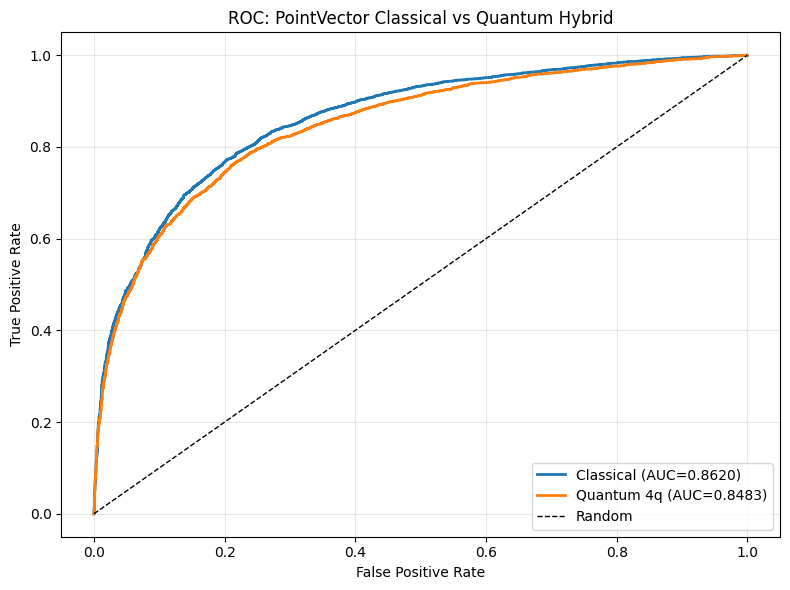

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))

clf_c = LogisticRegression(max_iter=1000).fit(train_emb, train_lab)
fpr_c, tpr_c, _ = roc_curve(test_lab, clf_c.predict_proba(test_emb_classical)[:, 1])
ax.plot(fpr_c, tpr_c, lw=2, label=f'Classical (AUC={classical_test_auc:.4f})')

clf_q = LogisticRegression(max_iter=1000).fit(train_emb_q, train_lab_q)
fpr_q, tpr_q, _ = roc_curve(test_lab, clf_q.predict_proba(test_emb_quantum)[:, 1])
ax.plot(fpr_q, tpr_q, lw=2, label=f'Quantum 4q (AUC={quantum_test_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC: PointVector Classical vs Quantum Hybrid')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_pointvector.png', dpi=150)
plt.show()

In [24]:
# Save models
torch.save({
    'classical_encoder': classical_encoder.state_dict(),
    'quantum_encoder': quantum_encoder.state_dict(),
    'classical_test_auc': classical_test_auc,
    'quantum_test_auc': quantum_test_auc,
    'config_classical': config_classical,
    'config_quantum': config_quantum
}, 'pointvector_models.pt')

print("Models saved!")

Models saved!


The quantum hybrid did not outperform the classical model. This was somewhat expected—given only 4 qubits and shallow depth, the circuit likely doesn’t have enough capacity to add meaningful structure beyond the classical encoder